In [3]:
# 01 Environment Setup

import sys

import qiskit
import qiskit_aer
import qiskit_ibm_runtime

print("Python:", sys.version.split()[0])
print("Qiskit:", qiskit.__version__)
print("Qiskit Aer:", qiskit_aer.__version__)
print("Qiskit IBM Runtime:", qiskit_ibm_runtime.__version__)

Python: 3.10.6
Qiskit: 2.4.2
Qiskit Aer: 0.17.2
Qiskit IBM Runtime: 0.47.0


{'0': 511, '1': 513}


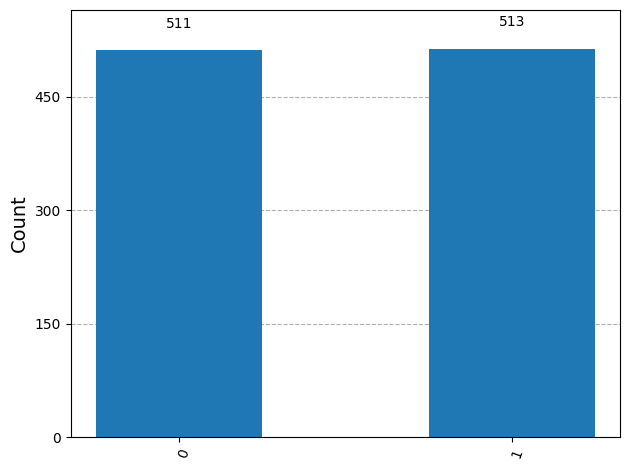

In [4]:
# running on a local simulator
from qiskit import QuantumCircuit
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# create a simple circuit with a hadamard gate
qc = QuantumCircuit(1)
qc.h(0)
qc.measure_all()
qc.draw("mpl")

# call the simulator
simulator = AerSimulator()

# Convert the circuit into a form suitable for the simulator
compiled_qc = transpile(qc, simulator)

# run the circuit shots = 1024
NUM_SHOTS = 1024
job = simulator.run(compiled_qc, shots=NUM_SHOTS)
result = job.result()
counts = result.get_counts()

print(counts)
# built-in histogram feature
plot_histogram(counts)

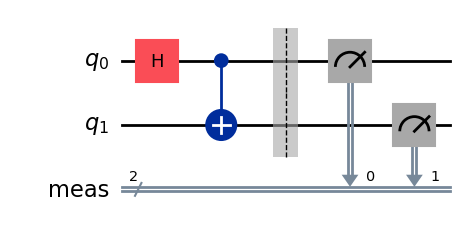

In [5]:
# Building a Bell State
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

NUM_SHOTS = 1024
# make the bell state, 2-qubit circuit
bell = QuantumCircuit(2)
bell.h(0)                   # hadamard gate applied to qubit 1
bell.cx(0, 1)               # control first, target second. qubit 1 controls qubit 2
bell.measure_all()

bell.draw("mpl")


{'11': 519, '00': 505}


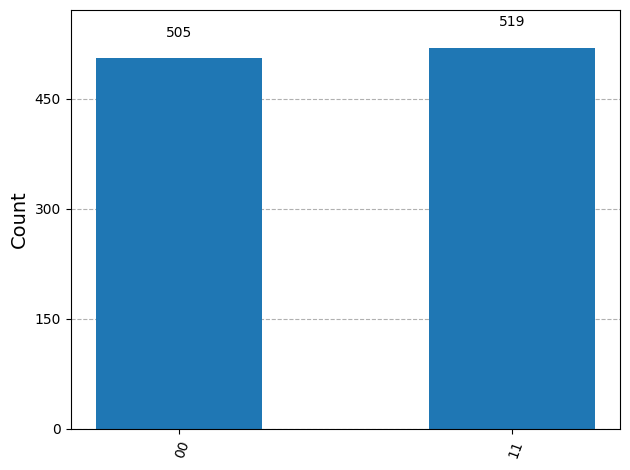

In [6]:
# run the simulation
simulator = AerSimulator()
compiled_bell = transpile(bell, simulator)
job = simulator.run(compiled_bell, shots=NUM_SHOTS)
counts = job.result().get_counts()

print(counts)
plot_histogram(counts)